(example_reproject)=

# Reproject dataset

In `faninsar`, to convert a dataset to another CRS—whether for analysis or visualization—you can use the `reproject` method provided by the dataset object. The `reproject` method takes a target CRS as its primary argument and returns a new dataset in the specified CRS.

In [1]:
from faninsar import datasets, cmaps
from faninsar.constants import Resampling
import matplotlib.pyplot as plt

In [12]:
file_hyp3 = "/Volumes/Data/Github/FanInSAR/tests/data/HyP3_ALOS2_Amplitude/HyP3_Amplitude.tif"

ds_hyp3 = datasets.RasterDataset(paths=[file_hyp3])

## Perform Reprojection

To reproject a dataset, simply call its `reproject` method and pass the desired `new_crs`. Optionally, you can also specify a `resampling` method and a `nodata` value, if required for your application.


In [10]:
ds_hyp3_wgs84 = ds_hyp3.reproject(
    new_crs="EPSG:4326",
    resampling=Resampling.bilinear,
)

## Visualize results

In [4]:
print(
    f"HyP3 Dataset:\n"
    f"  CRS: {ds_hyp3.crs}\n"
    f"  Resolution: {ds_hyp3.res}\n"
    f"  Shape: {ds_hyp3.shape}\n"
    f"  Bounds: {ds_hyp3.bounds}\n"
)

print(
    f"HyP3 Dataset (WGS84):\n"
    f"  CRS: {ds_hyp3_wgs84.crs}\n"
    f"  Resolution: {ds_hyp3_wgs84.res}\n"
    f"  Shape: {ds_hyp3_wgs84.shape}\n"
    f"  Bounds: {ds_hyp3_wgs84.bounds}\n"
)

HyP3 Dataset:
  CRS: EPSG:32647
  Resolution: (40.0, 40.0)
  Shape: (147, 97)
  Bounds: BoundingBox(left=488290.56541342364, bottom=4293071.467859996, right=492170.56541342364, top=4298951.467859996, crs=EPSG:32647)

HyP3 Dataset (WGS84):
  CRS: EPSG:4326
  Resolution: (0.00046158500173021366, 0.00036075794835753943)
  Shape: (147, 97)
  Bounds: BoundingBox(left=98.86507895791294, bottom=38.78618432144267, right=98.90996130207046, top=38.83933446583973, crs=EPSG:4326)



In [5]:
arr_hyp3 = ds_hyp3[ds_hyp3.bounds].boxes.data
arr_hyp3_wgs84 = ds_hyp3_wgs84[ds_hyp3_wgs84.bounds].boxes.data

Loading  Files: 100%|██████████| 1/1 [00:00<00:00, 1204.91 files/s]


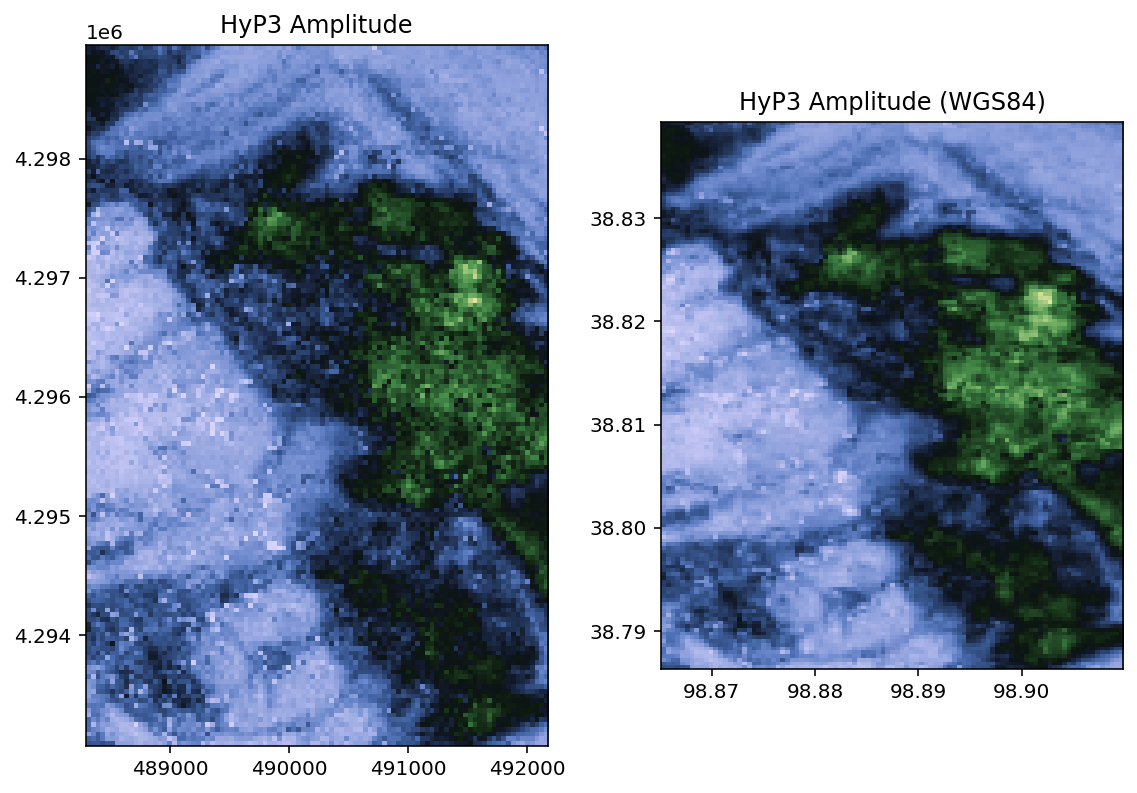

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(8, 6), dpi=144)
ds_hyp3.show(arr_hyp3[0], cmap=cmaps.tofino, ax=ax[0])
ax[0].set_title("HyP3 Amplitude")

ds_hyp3_wgs84.show(arr_hyp3_wgs84[0], cmap=cmaps.tofino, ax=ax[1])
ax[1].set_title("HyP3 Amplitude (WGS84)")
plt.tight_layout()
plt.show()